In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt"

df_co2 = pd.read_csv(
    url,
    comment="#",        
    sep="\s+",          
    header=None,        
    names=["year", "month", "decimal_date", "co2_avg", "co2_deseason", "ndays", "std", "unc"]
)

print(df_co2.shape)
print(df_co2.head(10))

(816, 8)
   year  month  decimal_date  co2_avg  co2_deseason  ndays   std   unc
0  1958      3     1958.2027   315.71        314.44     -1 -9.99 -0.99
1  1958      4     1958.2877   317.45        315.16     -1 -9.99 -0.99
2  1958      5     1958.3699   317.51        314.69     -1 -9.99 -0.99
3  1958      6     1958.4548   317.27        315.15     -1 -9.99 -0.99
4  1958      7     1958.5370   315.87        315.20     -1 -9.99 -0.99
5  1958      8     1958.6219   314.93        316.21     -1 -9.99 -0.99
6  1958      9     1958.7068   313.21        316.11     -1 -9.99 -0.99
7  1958     10     1958.7890   312.42        315.41     -1 -9.99 -0.99
8  1958     11     1958.8740   313.33        315.21     -1 -9.99 -0.99
9  1958     12     1958.9562   314.67        315.43     -1 -9.99 -0.99


In [3]:
!pip install netCDF4 xarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.8/22.8 MB 5.1 MB/s  0:00:045.2 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [netCDF4]


In [4]:
import xarray as xr
print("xarray hazır!")

xarray hazır!


In [6]:
import glob
nc_files = glob.glob("data/*.nc")
print("Bulunan dosyalar:")
for f in nc_files:
    print(f)

Bulunan dosyalar:


In [8]:
import os

print(os.getcwd()) 

/Users/melis


In [9]:
import os

os.chdir("/Users/melis/Desktop/climate-analysis")
print(os.getcwd())

/Users/melis/Desktop/climate-analysis


In [11]:
print(os.listdir("."))

['.DS_Store', 'data:']


In [13]:
print(os.listdir("data:"))

['SBBX.HadR2', 'SBBX1880.Ts.GHCNv4.1200', 'GlobalLandTemperaturesByCountry.csv', 'mlo_station_data_set.zip', '.DS_Store', 'SBBX1880.Ts.GHCNv4.250', 'gistemp250_GHCNv4.zarr.tar', 'GlobalLandTemperaturesByMajorCity.csv', 'gistemp250_GHCNv4.nc', 'gistemp1200_GHCNv4_ERSSTv5.nc', 'GlobalLandTemperaturesByState.csv', 'GlobalTemperatures.csv', 'gistemp1200_GHCNv4_ERSSTv5.zarr.tar', 'GlobalLandTemperaturesByCity.csv']


In [14]:
df_global = pd.read_csv("data:/GlobalTemperatures.csv")

print(df_global.shape)
print(df_global.head())

(3192, 9)
           dt  LandAverageTemperature  LandAverageTemperatureUncertainty  \
0  1750-01-01                   3.034                              3.574   
1  1750-02-01                   3.083                              3.702   
2  1750-03-01                   5.626                              3.076   
3  1750-04-01                   8.490                              2.451   
4  1750-05-01                  11.573                              2.072   

   LandMaxTemperature  LandMaxTemperatureUncertainty  LandMinTemperature  \
0                 NaN                            NaN                 NaN   
1                 NaN                            NaN                 NaN   
2                 NaN                            NaN                 NaN   
3                 NaN                            NaN                 NaN   
4                 NaN                            NaN                 NaN   

   LandMinTemperatureUncertainty  LandAndOceanAverageTemperature  \
0       

In [15]:
print(df_global.columns.tolist())
print(df_global.dtypes)
print(df_global.isnull().sum())

['dt', 'LandAverageTemperature', 'LandAverageTemperatureUncertainty', 'LandMaxTemperature', 'LandMaxTemperatureUncertainty', 'LandMinTemperature', 'LandMinTemperatureUncertainty', 'LandAndOceanAverageTemperature', 'LandAndOceanAverageTemperatureUncertainty']
dt                                            object
LandAverageTemperature                       float64
LandAverageTemperatureUncertainty            float64
LandMaxTemperature                           float64
LandMaxTemperatureUncertainty                float64
LandMinTemperature                           float64
LandMinTemperatureUncertainty                float64
LandAndOceanAverageTemperature               float64
LandAndOceanAverageTemperatureUncertainty    float64
dtype: object
dt                                              0
LandAverageTemperature                         12
LandAverageTemperatureUncertainty              12
LandMaxTemperature                           1200
LandMaxTemperatureUncertainty                1200


In [18]:
df_global["dt"] = pd.to_datetime(df_global["dt"])
df_global["year"] = df_global["dt"].dt.year
df_global = df_global.dropna(subset=["LandAverageTemperature"])

print("Temizlendi! ✓")
print(df_global.shape)
print(df_global.head())
                            

Temizlendi! ✓
(3180, 10)
          dt  LandAverageTemperature  LandAverageTemperatureUncertainty  \
0 1750-01-01                   3.034                              3.574   
1 1750-02-01                   3.083                              3.702   
2 1750-03-01                   5.626                              3.076   
3 1750-04-01                   8.490                              2.451   
4 1750-05-01                  11.573                              2.072   

   LandMaxTemperature  LandMaxTemperatureUncertainty  LandMinTemperature  \
0                 NaN                            NaN                 NaN   
1                 NaN                            NaN                 NaN   
2                 NaN                            NaN                 NaN   
3                 NaN                            NaN                 NaN   
4                 NaN                            NaN                 NaN   

   LandMinTemperatureUncertainty  LandAndOceanAverageTemperature  \

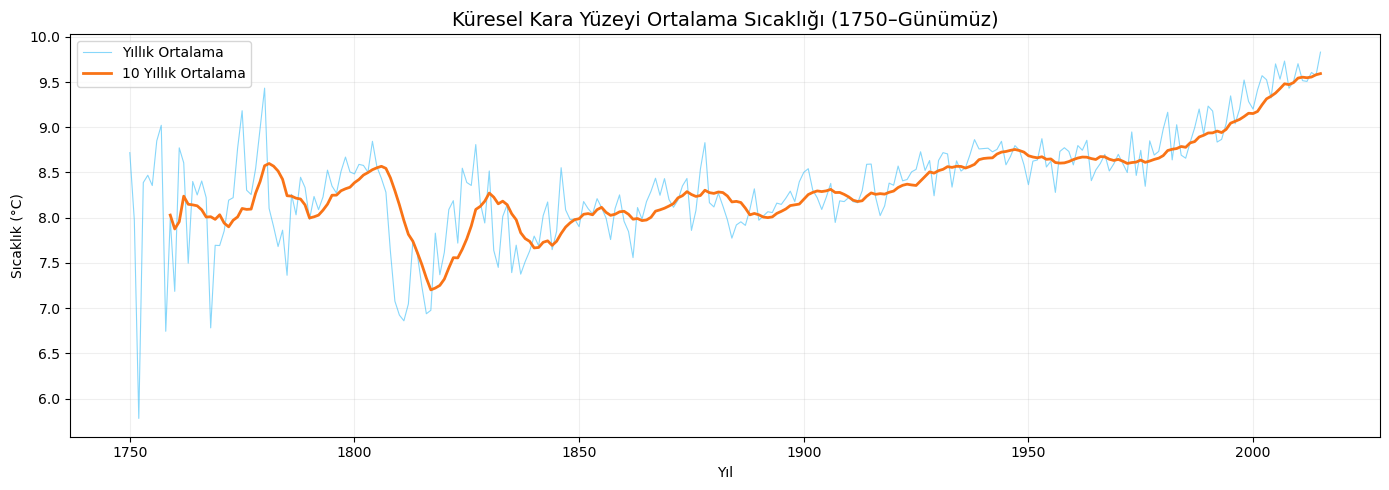

In [19]:

df_yearly = df_global.groupby("year")["LandAverageTemperature"].mean().reset_index()
plt.figure(figsize=(14, 5))
plt.plot(df_yearly["year"], df_yearly["LandAverageTemperature"], 
         color="#38bdf8", linewidth=0.8, alpha=0.6, label="Yıllık Ortalama")
df_yearly["rolling"] = df_yearly["LandAverageTemperature"].rolling(10).mean()
plt.plot(df_yearly["year"], df_yearly["rolling"], 
         color="#f97316", linewidth=2, label="10 Yıllık Ortalama")

plt.title("Küresel Kara Yüzeyi Ortalama Sıcaklığı (1750–Günümüz)", fontsize=14)
plt.xlabel("Yıl")
plt.ylabel("Sıcaklık (°C)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Gözlem 1: Küresel Isınma Trendi

1750'den günümüze küresel kara yüzeyi sıcaklığı incelendiğinde,
özellikle **1900lerin başından itibaren** belirgin bir artış trendi gözlemlenmektedir.
10 yıllık hareketli ortalama bu trendi daha net ortaya koymaktadır.

In [22]:
df_country = pd.read_csv("data:/GlobalLandTemperaturesBycountry.csv")
print(df_country.shape)
print(df_country.head())

(577462, 4)
           dt  AverageTemperature  AverageTemperatureUncertainty Country
0  1743-11-01               4.384                          2.294   Åland
1  1743-12-01                 NaN                            NaN   Åland
2  1744-01-01                 NaN                            NaN   Åland
3  1744-02-01                 NaN                            NaN   Åland
4  1744-03-01                 NaN                            NaN   Åland


In [23]:
df_country["dt"] = pd.to_datetime(df_country["dt"])
df_country["year"] = df_country["dt"].dt.year
df_country = df_country.dropna(subset=["AverageTemperature"])
df_turkey = df_country[df_country["Country"] == "Turkey"]
print(df_turkey.shape)
print(df_turkey.head())

(2838, 5)
               dt  AverageTemperature  AverageTemperatureUncertainty Country  \
533683 1777-02-01               3.000                          3.314  Turkey   
533685 1777-04-01               7.678                          2.553  Turkey   
533686 1777-05-01              15.293                          3.189  Turkey   
533687 1777-06-01              18.661                          2.993  Turkey   
533688 1777-07-01              20.757                          2.643  Turkey   

        year  
533683  1777  
533685  1777  
533686  1777  
533687  1777  
533688  1777  


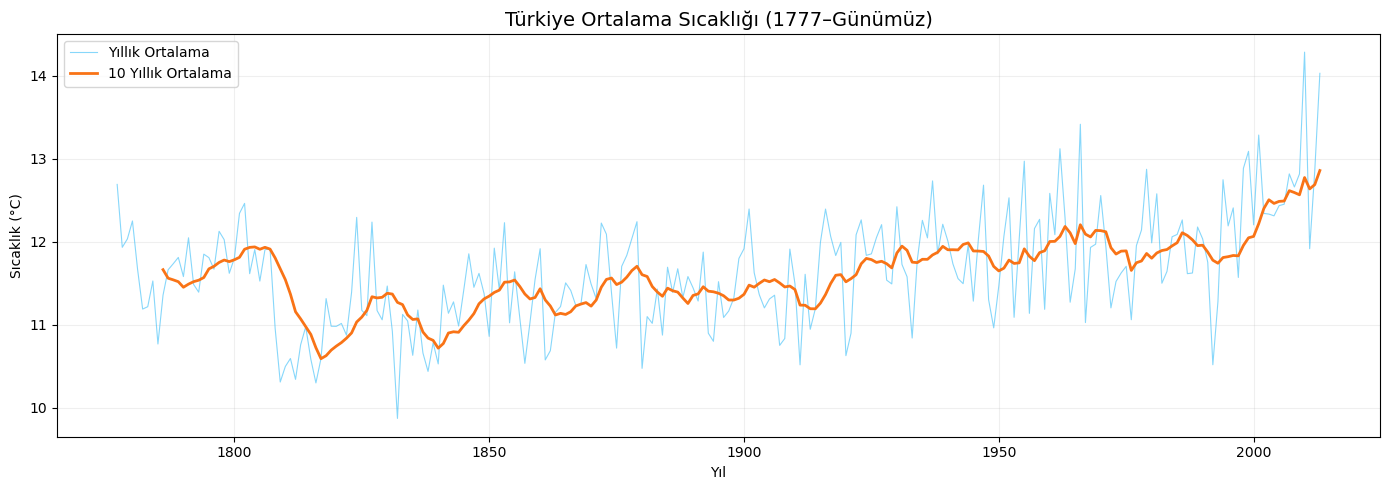

In [24]:
df_turkey_yearly = df_turkey.groupby("year")["AverageTemperature"].mean().reset_index()
plt.figure(figsize=(14, 5))
plt.plot(df_turkey_yearly["year"], df_turkey_yearly["AverageTemperature"],
         color="#38bdf8", linewidth=0.8, alpha=0.6, label="Yıllık Ortalama")
df_turkey_yearly["rolling"] = df_turkey_yearly["AverageTemperature"].rolling(10).mean()
plt.plot(df_turkey_yearly["year"], df_turkey_yearly["rolling"],
         color="#f97316", linewidth=2, label="10 Yıllık Ortalama")
plt.title("Türkiye Ortalama Sıcaklığı (1777–Günümüz)", fontsize=14)
plt.xlabel("Yıl")
plt.ylabel("Sıcaklık (°C)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Gözlem 2: Türkiye'de İklim Değişikliği

Türkiye'nin 1777'den günümüze sıcaklık verisi incelendiğinde,
**2000'li yıllardan itibaren** belirgin bir sıcaklık artışı gözlemlenmektedir.
Bu trend, küresel ısınma ile paralel bir seyir izlemektedir.

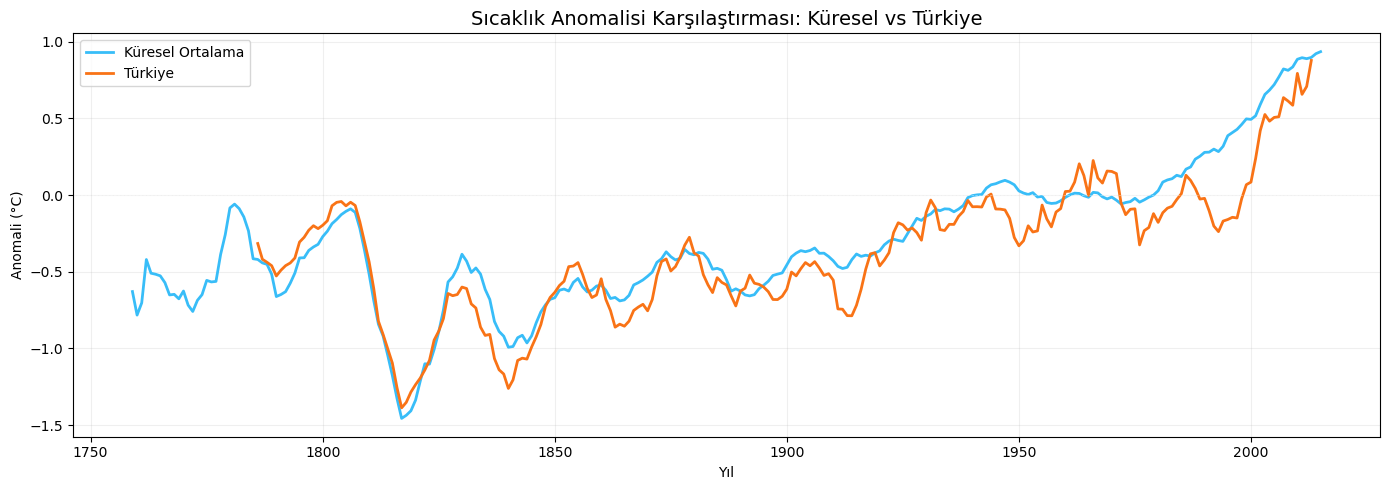

In [25]:
base_global = df_yearly[df_yearly["year"].between(1951, 1980)]["LandAverageTemperature"].mean()
base_turkey = df_turkey_yearly[df_turkey_yearly["year"].between(1951, 1980)]["AverageTemperature"].mean()
df_yearly["anomaly"] = df_yearly["LandAverageTemperature"] - base_global
df_turkey_yearly["anomaly"] = df_turkey_yearly["AverageTemperature"] - base_turkey

plt.figure(figsize=(14, 5))
plt.plot(df_yearly["year"], df_yearly["anomaly"].rolling(10).mean(),
         color="#38bdf8", linewidth=2, label="Küresel Ortalama")
plt.plot(df_turkey_yearly["year"], df_turkey_yearly["anomaly"].rolling(10).mean(),
         color="#f97316", linewidth=2, label="Türkiye")
plt.axhline(0, color="white", linewidth=0.5, linestyle="--", alpha=0.5)
plt.title("Sıcaklık Anomalisi Karşılaştırması: Küresel vs Türkiye", fontsize=14)
plt.xlabel("Yıl")
plt.ylabel("Anomali (°C)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Gözlem 3: Küresel vs Türkiye Karşılaştırması

1951-1980 baz dönemi referans alındığında, hem küresel hem de Türkiye sıcaklık
anomalileri **1900'lerden itibaren** belirgin bir artış göstermektedir.
İki trend birbirine paralel seyretmekte olup Türkiye, küresel ısınmadan
doğrudan etkilenen bir ülke konumundadır.